# 05 — Machine Learning: Predicting High-Grade Intervals

## Introduction

This notebook builds a binary classification model to predict whether a drillhole interval is high-grade based on its geological attributes alone — lithology, alteration type, alteration intensity, and sulphide content.

The target variable is defined as intervals exceeding the dataset-wide Cu p90 threshold of 0.228%, computed across all 7608 intervals in the 2023 MPD drill program. This places roughly 10% of intervals in the high-grade class and 90% in the background class.

The geological controls identified in Notebooks 03 and 04 — particularly the SKN + MM combination and high-intensity skarn alteration — provide a strong prior expectation that these features will carry predictive power. The ML analysis tests whether those relationships are strong enough to generalise into a reliable predictive model.

If successful, this model could be applied to new drill programs in the same geological setting to flag high-grade intervals before assay results are returned from the lab — accelerating exploration decision-making.

A key stretch goal for this project is to train the model on the 2023 drill program and validate it against the 2024 MPD drill program as a true temporal holdout — testing whether geological controls identified in 2023 generalise to new holes drilled in the same system. The 2024 ARIS assessment report was not yet publicly available at the time of writing. This validation will be completed when the data becomes available.

1. **Define the Problem**
    - 1.1 Load Data and Compute Dataset-Wide Cu p90 Threshold
    - 1.2 Define Target Variable
    - 1.3 Select Features

2. **Exploratory Feature Analysis**
    - 2.1 Class Balance
    - 2.2 Feature Distributions
    - 2.3 Correlation with Target

3. **Preprocessing Pipeline**
    - 3.1 Handle Duplicates and Missing Values
    - 3.2 Encode Categorical Features
    - 3.3 Remove Sparse Categories
    - 3.4 Train/Test Split
    - 3.5 Feature Scaling

4. **Model Training and Tuning**
    - 4.1 Logistic Regression
    - 4.2 Support Vector Machine
    - 4.3 Random Forest
    - 4.4 Bagging Classifier
    - 4.5 Gradient Boosting
    - 4.6 XGBoost

5. **Model Comparison**
    - 5.1 Evaluation Metrics
    - 5.2 ROC Curves
    - 5.3 Comparison Table

6. **Best Model Deep Dive**
    - 6.1 Feature Importances
    - 6.2 Confusion Matrix
    - 6.3 Geological Validation

7. **Limitations and Geological Context**

**1.1 Load Data and Compute Dataset-Wide Cu p90 Threshold**

The Cu p90 threshold computed here is calculated across all 7608 intervals in the merged dataset — not on a per-hole basis. This is an important distinction from Notebook 04, where p90 was computed per hole to score and rank individual drillholes against each other.

In [3]:
import pandas as pd
import numpy as np

# Load the merged dataset
merged_intervals_df = pd.read_csv("../Data/processed/merged_intervals.csv")

# Compute Cu p90 threshold
cu_p90 = merged_intervals_df['cu_best_pct'].quantile(0.90)
print(f"Cu p90 threshold: {cu_p90:.4f}%")

# Preview grade distribution
print(f"\nCu grade summary:")
print(merged_intervals_df['cu_best_pct'].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95]))

Cu p90 threshold: 0.2280%

Cu grade summary:
count    7608.000000
mean        0.103931
std         0.249114
min         0.000130
25%         0.011500
50%         0.042000
75%         0.116000
90%         0.228000
95%         0.320300
max         5.430000
Name: cu_best_pct, dtype: float64


**1.1 Outcome**

The dataset-wide p90 threshold of 0.228% Cu is used to define high-grade intervals. The median Cu grade of 0.042% was considered but rejected — at that level the split is not geologically meaningful, as it simply separates weak mineralisation from background rock rather than identifying genuinely anomalous intervals. The p90 threshold results in roughly a 90/10 class split which will be addressed in the preprocessing section.

**1.2 Define Target Variable**

Using the p90 threshold computed in 1.1, each interval is assigned a binary label — 1 for high-grade (Cu ≥ 0.228%) and 0 for background. This becomes the target variable that all models will be trained to predict. 

In [4]:
# -- 1.2 Define Target Variable --

# Assign binary label based on dataset-wide Cu p90 threshold
merged_intervals_df['high_grade_cu'] = (
    merged_intervals_df['cu_best_pct'] >= cu_p90
).astype(int)

# Confirm class distribution
class_counts = merged_intervals_df['high_grade_cu'].value_counts()
class_pct    = merged_intervals_df['high_grade_cu'].value_counts(normalize=True) * 100

print(f"Class distribution:")
print(f"    Background (0): {class_counts[0]} intervals ({class_pct[0]:.1f}%)")
print(f"    High-grade Cu (1): {class_counts[1]} intervals ({class_pct[1]:.1f}%)")  

Class distribution:
    Background (0): 6840 intervals (89.9%)
    High-grade Cu (1): 768 intervals (10.1%)


**1.3 Select Features**

Based on the geological controls identified in Notebooks 03 and 04, the following features are selected for modelling. All features are derived from geological logging — no assay data is used as a predictor, since the goal is to predict grade from geology alone.

- `base_lithology` — rock type (categorical)
- `dominant_alteration` — alteration style (categorical)
- `intensity` — alteration intensity, 1–7 scale (numerical)
- `py_pct_nv` — pyrite percentage (numerical)
- `ccp_pct_nv` — chalcopyrite percentage (numerical)
- `bn_pct_nv` — bornite percentage (numerical)

In [5]:
# ── 1.3 Select Features ───────────────────────────────────────────────────────

features = [
    'base_lithology',       # categorical — rock type
    'dominant_alteration',  # categorical — alteration style
    'intensity',            # numerical  — alteration intensity
    'py_pct_nv',            # numerical  — pyrite %
    'ccp_pct_nv',           # numerical  — chalcopyrite %
    'bn_pct_nv',            # numerical  — bornite %
]

target = 'high_grade_cu'

# Confirm all feature columns exist in the dataset
missing = [f for f in features if f not in merged_intervals_df.columns]
print(f"Missing columns: {missing if missing else 'None — all features present'}")

# Preview feature data
merged_intervals_df[features + [target]].head()

Missing columns: None — all features present


,base_lithology,dominant_alteration,intensity,py_pct_nv,ccp_pct_nv,bn_pct_nv,high_grade_cu
0,DIO,PRO,4.0,2.0,0.1,0.0,1
1,DIO,PRO,4.0,2.0,0.1,0.0,1
2,DIO,PRO,4.0,2.0,0.1,0.0,0
3,DIO,PHY,4.0,2.0,0.1,0.0,0
4,DIO,PHY,4.0,2.0,0.1,0.0,1


### 2. Exploratory Feature Analysis

Before building any models, we examine the feature distributions and their relationship with the target variable. This confirms that the geological controls identified in Notebooks 03 and 04 are visible in the data and provides a baseline expectation for which features should carry the most predictive power.

**2.1 Class Balance**

The class distribution is visualised to confirm the 90/10 split and set expectations for how class imbalance will affect model training.

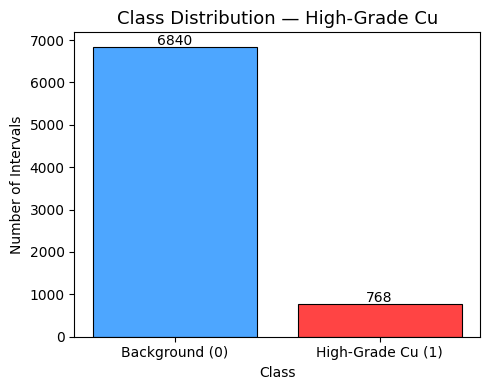

In [6]:
# ── 2.1 Class Balance ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))

class_counts = merged_intervals_df[target].value_counts()
ax.bar(['Background (0)', 'High-Grade Cu (1)'], 
       class_counts.values,
       color=['#4da6ff', '#ff4444'],
       edgecolor='black',
       linewidth=0.8)

ax.set_title('Class Distribution — High-Grade Cu', fontsize=13)
ax.set_ylabel('Number of Intervals')
ax.set_xlabel('Class')

for i, v in enumerate(class_counts.values):
    ax.text(i, v + 50, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

**2.2 Feature Distributions**

The distribution of each feature is examined separately for high-grade and background intervals. If the geological controls identified in Notebooks 03 and 04 are real, we would expect to see meaningful differences in feature distributions between the two classes.

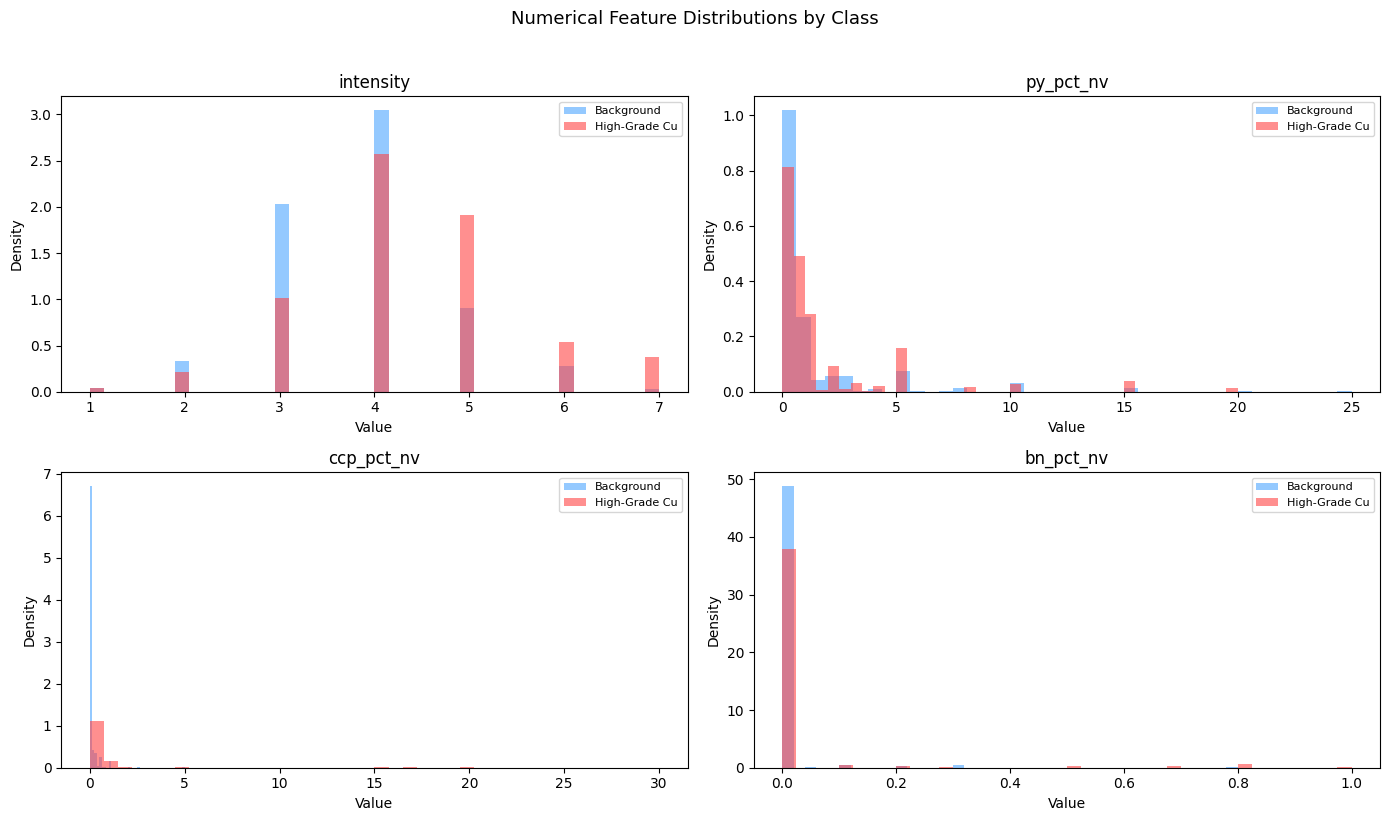

In [7]:
# ── 2.2 Numerical Feature Distributions ────────────────────────────────────────────────

numerical_features   = ['intensity', 'py_pct_nv', 'ccp_pct_nv', 'bn_pct_nv']
categorical_features = ['base_lithology', 'dominant_alteration']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(numerical_features):
    ax = axes[i]
    for label, color, name in [(0, '#4da6ff', 'Background'), 
                                (1, '#ff4444', 'High-Grade Cu')]:
        subset = merged_intervals_df[merged_intervals_df[target] == label][feat].dropna()
        ax.hist(subset, bins=40, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(feat)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Numerical Feature Distributions by Class', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

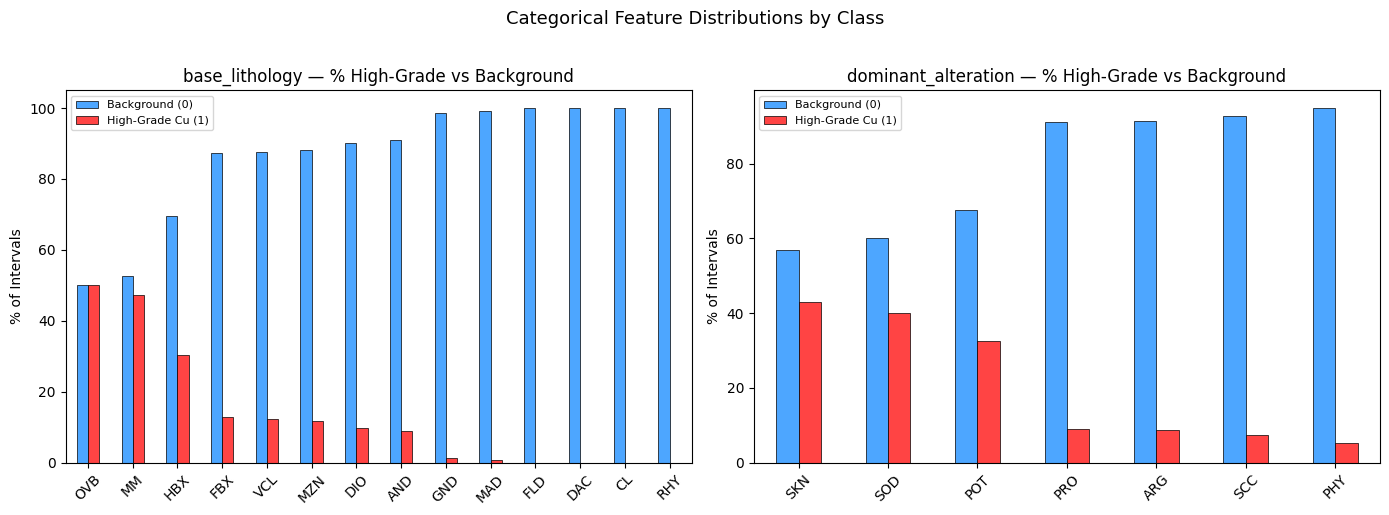

In [8]:
# ── Categorical feature distributions ────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, feat in enumerate(categorical_features):
    ax = axes[i]
    # Create a outcome table of counts for each category and class
    counts = merged_intervals_df.groupby([feat, target]).size().unstack(fill_value=0)
    counts_pct = counts.div(counts.sum(axis=1), axis=0) * 100
    
    # Sort by high-grade proportion to show most promising categories first
    counts_pct = counts_pct.sort_values(1, ascending=False)
    # Plot the percentage distribution as a bar chart
    counts_pct.plot(
        kind='bar',
        ax=ax,
        color=['#4da6ff', '#ff4444'],
        edgecolor='black',
        linewidth=0.5
    )
    ax.set_title(f'{feat} — % High-Grade vs Background')
    ax.set_xlabel('')
    ax.set_ylabel('% of Intervals')
    ax.legend(['Background (0)', 'High-Grade Cu (1)'], fontsize=8)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Categorical Feature Distributions by Class', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [9]:
# ── Interval counts per category ─────────────────────────────────────────────
# This shows the total number of intervals and the percentage that are high-grade Cu for each lithology and alteration type. Categories with a higher percentage of high-grade intervals may be more prospective.
lith_counts = (
    merged_intervals_df.groupby('base_lithology')[target]
    .agg(total='count', high_grade_cu='sum')
    .assign(pct_high_grade_cu=lambda x: (x['high_grade_cu'] / x['total'] * 100).round(1))
    .sort_values('pct_high_grade_cu', ascending=False)
)

alt_counts = (
    merged_intervals_df.groupby('dominant_alteration')[target]
    .agg(total='count', high_grade_cu='sum')
    .assign(pct_high_grade_cu=lambda x: (x['high_grade_cu'] / x['total'] * 100).round(1))
    .sort_values('pct_high_grade_cu', ascending=False)
)

print("Lithology interval counts:")
display(lith_counts)

print("\nAlteration interval counts:")
display(alt_counts)

Lithology interval counts:


,total,high_grade_cu,pct_high_grade_cu
base_lithology,,,
OVB,2,1,50.0
MM,112,53,47.3
HBX,102,31,30.4
FBX,86,11,12.8
VCL,946,116,12.3
MZN,424,50,11.8
DIO,2881,280,9.7
AND,2463,221,9.0
GND,307,4,1.3



Alteration interval counts:


,total,high_grade_cu,pct_high_grade_cu
dominant_alteration,,,
SKN,230,99,43.0
SOD,20,8,40.0
POT,287,93,32.4
PRO,4492,403,9.0
ARG,393,34,8.7
SCC,684,50,7.3
PHY,1432,74,5.2


**2.2 Outcome**

The feature distributions confirm the geological controls identified in 
Notebooks 03 and 04 are visible in the data:

- **Intensity** shows the clearest numerical signal — high-grade intervals 
  skew toward intensities of 5–7 while background intervals peak at 4
- **CCP and BN percentages** are heavily zero-dominated in both classes, 
  reflecting the sparse nature of sulphide logging — these features may 
  carry limited predictive power
- **MM lithology** is the strongest meaningful lithology signal with 47.3% 
  of its 112 intervals classified as high-grade
- **SKN alteration** is the strongest alteration signal with 43.0% of its 
  230 intervals classified as high-grade

Two important caveats — OVB (overburden — the loose unconsolidated material above bedrock) appears at the top of the lithology table with 50% high-grade, but represents only 2 intervals. Similarly SOD alteration shows 40% high-grade but has only 20 intervals. Both figures are statistically unreliable and should not be interpreted as meaningful geological signals. These rare categories will be filtered out in the preprocessing pipeline to prevent the model from learning spurious patterns from insufficient data.

**2.3 Correlation with Target**

A point-biserial correlation is computed between each numerical feature and the binary target variable. Point-biserial is the appropriate correlation measure when one variable is continuous (e.g. intensity, sulphide percentages) and the other is binary (high-grade: 0 or 1) — it measures how strongly each feature is associated with the high-grade classification. A value closer to 1 indicates a strong positive relationship, closer to 0 indicates little to no relationship.

In [10]:
# ── 2.3 Correlation with Target ───────────────────────────────────────────────
from scipy import stats
numerical_features = ['intensity', 'py_pct_nv', 'ccp_pct_nv', 'bn_pct_nv']

correlation_results = []
# We use point biserial correlation since the target is binary and the features are continuous. This will show how strongly each numerical feature is associated with being a high-grade Cu interval.
for feat in numerical_features:
    # Drop rows where either the feature or target is null
    subset = merged_intervals_df[[feat, target]].dropna()
    
    # Calculate point biserial correlation and p-value
    corr, pvalue = stats.pointbiserialr(
        subset[target],
        subset[feat]
    )
    # Store results in a list of dictionaries for easy conversion to DataFrame
    correlation_results.append({
        'feature':     feat,
        'correlation': round(corr, 4),
        'p_value':     round(pvalue, 4),
        'significant': 'Yes' if pvalue < 0.05 else 'No'
    })
# Display correlation results sorted by absolute correlation value
corr_df = pd.DataFrame(correlation_results).sort_values('correlation', ascending=False)
display(corr_df)

,feature,correlation,p_value,significant
2,ccp_pct_nv,0.2295,0.0000,Yes
0,intensity,0.1771,0.0000,Yes
3,bn_pct_nv,0.1063,0.0000,Yes
1,py_pct_nv,0.0395,0.0008,Yes


**2.3 Outcome**

All four numerical features show statistically significant correlations 
with the high-grade target (p < 0.05), confirming they carry some 
predictive signal. However the correlations are weak:

- **CCP (chalcopyrite %)** is the strongest predictor at 0.23 — consistent 
  with chalcopyrite being the primary copper-bearing sulphide
- **Intensity** follows at 0.18 — higher alteration intensity is associated 
  with high-grade intervals as expected from the Section 3 findings
- **BN (bornite %)** at 0.11 — a weaker but significant signal
- **PY (pyrite %)** at 0.04 — the weakest correlation, consistent with 
  pyrite being a pathfinder mineral rather than a Cu host

The weak correlations are not surprising — grade in a porphyry system is controlled by the combination of multiple geological factors rather than any single variable. This is exactly why ensemble models like Random Forest and Gradient Boosting are well suited here — they can capture non-linear interactions between features that a simple correlation cannot detect.

### 3. Preprocessing Pipeline

Before training any models, the dataset needs to be cleaned and prepared. This section handles duplicate intervals from the overlap join, missing values, rare categories, categorical encoding, train/test splitting, and feature scaling.

**3.1 Handle Duplicates and Missing Values**

The depth-based overlap join in Notebook 03 can produce duplicate rows where a single assay interval straddles a geology boundary — appearing once for each overlapping geology interval. These duplicates must be removed before modelling to prevent data leakage and inflated sample sizes. Missing values in sulphide columns are imputed with zero — if no sulphides were logged it is reasonable to assume trace or zero sulphide content.

In [11]:
# ── Investigate straddling intervals before removing duplicates ───────────────

# Identify straddling intervals — rows where the same assay interval 
# appears more than once due to overlapping geology boundaries
straddling = merged_intervals_df[merged_intervals_df.duplicated(subset=['hole_id', 'assay_from', 'assay_to'], keep=False)]

print(f"Total straddling rows: {len(straddling)}")
print(f"Unique straddling intervals: {straddling.groupby(['hole_id', 'assay_from', 'assay_to']).ngroups}")

# Show what geology assignments differ across duplicates
print("\nExample — conflicting geology assignments for straddling intervals:")
example = (
    straddling
    .groupby(['hole_id', 'assay_from', 'assay_to'])[['base_lithology', 'dominant_alteration']]
    .nunique()
)
print(f"Intervals with conflicting lithology: {(example['base_lithology'] > 1).sum()}")
print(f"Intervals with conflicting alteration: {(example['dominant_alteration'] > 1).sum()}")

Total straddling rows: 2276
Unique straddling intervals: 642

Example — conflicting geology assignments for straddling intervals:
Intervals with conflicting lithology: 84
Intervals with conflicting alteration: 143


In [12]:
# Reload fresh to investigate before deduplication
df_raw = pd.read_csv("../Data/processed/merged_intervals.csv")

dupes = df_raw[df_raw.duplicated(subset=['hole_id', 'assay_from', 'assay_to'], keep=False)]

print(f"Total duplicate rows: {len(dupes)}")

fully_identical = df_raw.duplicated(keep=False)
print(f"Fully identical rows: {fully_identical.sum()}")

print("\nSample duplicate rows:")
sample = dupes.groupby(['hole_id', 'assay_from', 'assay_to']).head(2)
display(sample[['hole_id', 'assay_from', 'assay_to', 'base_lithology', 'dominant_alteration', 'cu_best_pct']].head(10))


Total duplicate rows: 2276
Fully identical rows: 419

Sample duplicate rows:


,hole_id,assay_from,assay_to,base_lithology,dominant_alteration,cu_best_pct
2,AXE-23-001,11.00,14.00,DIO,PRO,0.10700
3,AXE-23-001,11.00,14.00,DIO,PHY,0.10700
8,AXE-23-001,23.14,26.35,DIO,PHY,0.39200
9,AXE-23-001,23.14,26.35,DIO,SKN,0.39200
10,AXE-23-001,26.35,29.00,FBX,SKN,0.41700
11,AXE-23-001,26.35,29.00,FBX,SKN,0.41700
14,AXE-23-001,35.00,39.00,FBX,SKN,0.42100
15,AXE-23-001,35.00,39.00,FBX,PHY,0.42100
20,AXE-23-001,59.00,60.05,AND,PRO,0.00357
21,AXE-23-001,59.00,60.05,AND,PRO,0.00549


In [13]:
# ── 3.1 Handle Duplicates and Missing Values ──────────────────────────────────

# Step 1 — Remove duplicate assay intervals from overlap join
# Keep first occurrence per hole/depth combination
df = merged_intervals_df.copy()

before = len(df)
df = df.drop_duplicates(subset=['hole_id', 'assay_from', 'assay_to'])
after = len(df)
print(f"Rows removed (duplicates): {before - after}")
print(f"Rows remaining: {after}")

# Step 2 — Impute missing sulphide values with zero
sulphide_cols = ['py_pct_nv', 'ccp_pct_nv', 'bn_pct_nv']
df[sulphide_cols] = df[sulphide_cols].fillna(0)

# Step 3 — Drop rows with missing values in remaining features
df = df.dropna(subset=['base_lithology', 'dominant_alteration', 'intensity'])

print(f"Rows after dropping missing geology: {len(df)}")

Rows removed (duplicates): 1634
Rows remaining: 5974
Rows after dropping missing geology: 5908


**3.1 Outcome**

Investigation of the raw merged dataset revealed two types of duplicate rows:

- **419 fully identical rows** — exact duplicates likely caused by duplicate entries in the source geology tables. These are dropped with no information loss.
- **1857 straddling intervals** (2276 - 419) — assay samples that cross a geology boundary and were matched to multiple geology intervals. Of these:
  - **84 intervals have conflicting lithology assignments** — the sample could belong to either of two different rock types
  - **143 intervals have conflicting alteration assignments** — the sample ould belong to either of two different alteration zones
  - The first occurrence is retained for each straddling interval, meaning some intervals may carry an incorrect geology label. This is an inherent limitation of the overlap join approach and is acknowledged in Section 7.
- **66 rows dropped** — missing lithology, alteration, or intensity values
- **5908 intervals remaining** — cleaned dataset ready for modelling

**3.2 Encode Categorical Features**

Machine learning models require numerical inputs — categorical features like lithology and alteration type must be converted to numbers before training. Two encoding approaches are used:

- **Ordinal encoding** for `intensity` — already numerical but confirmed 
  as ordered (1 = weakest, 7 = strongest)
- **One-hot encoding** for `base_lithology` and `dominant_alteration` — 
  creates a binary column for each category so the model treats each 
  geology type independently without implying any numerical ordering

In [14]:
# ── 3.2 Encode Categorical Features ──────────────────────────────────────────

from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Select modelling features and target from cleaned dataset
X = df[features].copy()
y = df[target].copy()

# One-hot encode categorical features
X_encoded = pd.get_dummies(X, columns=['base_lithology', 'dominant_alteration'])

print(f"Features before encoding: {len(features)}")
print(f"Features after encoding:  {X_encoded.shape[1]}")
print(f"\nEncoded feature names:")
print(X_encoded.columns.tolist())

Features before encoding: 6
Features after encoding:  25

Encoded feature names:
['intensity', 'py_pct_nv', 'ccp_pct_nv', 'bn_pct_nv', 'base_lithology_AND', 'base_lithology_CL', 'base_lithology_DAC', 'base_lithology_DIO', 'base_lithology_FBX', 'base_lithology_FLD', 'base_lithology_GND', 'base_lithology_HBX', 'base_lithology_MAD', 'base_lithology_MM', 'base_lithology_MZN', 'base_lithology_OVB', 'base_lithology_RHY', 'base_lithology_VCL', 'dominant_alteration_ARG', 'dominant_alteration_PHY', 'dominant_alteration_POT', 'dominant_alteration_PRO', 'dominant_alteration_SCC', 'dominant_alteration_SKN', 'dominant_alteration_SOD']


**3.2 Outcome**

6 input features expanded to 25 after one-hot encoding — 14 lithology columns and 7 alteration columns plus the 4 original numerical features. 

One-hot encoding creates one binary column per category — for example `base_lithology_MM` is 1 if the interval is monzonite and 0 otherwise. This means categories with very few intervals produce columns that are almost entirely zeros — these are called sparse columns and provide little to no useful signal for the model.

In Section 2.2 we identified several sparse categories with very few intervals that produce unreliable high-grade proportions due to small sample sizes. The corresponding encoded columns will be dropped in 3.3:

- `base_lithology_OVB` — only 2 intervals
- `base_lithology_RHY` — only 1 interval
- `base_lithology_CL` — only 3 intervals
- `dominant_alteration_SOD` — only 20 intervals

Dropping these columns prevents the model from learning patterns that are statistically unreliable and unlikely to generalise to new data.

**3.3 Remove Sparse Categories and Apply Minimum Sample Filter**

Encoded columns representing categories with fewer than 30 intervals are removed before modelling. With a 90/10 class imbalance, a category with only 10 intervals would be expected to contain just 1 high-grade interval — far too few for the model to learn a reliable pattern. At 30 intervals, roughly 3 high-grade examples are expected — a reasonable minimum for meaningful inference. Categories below this threshold were already flagged as statistically unreliable in Section 2.2.

In [15]:
# ── 3.3 Remove Sparse Categories ─────────────────────────────────────────────

# Identify encoded columns for categories with fewer than 30 intervals
min_samples = 30

# Get original category counts before encoding
lith_counts = df['base_lithology'].value_counts()
alt_counts  = df['dominant_alteration'].value_counts()

# Identify rare categories
rare_lith = lith_counts[lith_counts < min_samples].index.tolist()
rare_alt  = alt_counts[alt_counts < min_samples].index.tolist()

print(f"Rare lithology categories (< {min_samples} intervals): {rare_lith}")
print(f"Rare alteration categories (< {min_samples} intervals): {rare_alt}")

# Drop corresponding encoded columns
cols_to_drop = (
    [f'base_lithology_{c}' for c in rare_lith] +
    [f'dominant_alteration_{c}' for c in rare_alt]
)

X_encoded = X_encoded.drop(columns=cols_to_drop, errors='ignore')


print(f"\nColumns dropped: {cols_to_drop}")
print(f"Features remaining: {X_encoded.shape[1]}")

# Store final feature names after sparse category removal
feature_names = X_encoded.columns.tolist()

Rare lithology categories (< 30 intervals): ['OVB', 'CL', 'RHY']
Rare alteration categories (< 30 intervals): ['SOD']

Columns dropped: ['base_lithology_OVB', 'base_lithology_CL', 'base_lithology_RHY', 'dominant_alteration_SOD']
Features remaining: 21


**3.3 Outcome**

4 sparse columns dropped — 3 lithology categories (OVB, CL, RHY) and 1 alteration category (SOD) — all with fewer than 30 intervals. The cleaned feature matrix contains 21 columns ready for train/test splitting.

**3.4 Train/Test Split**

The dataset is split into training and test sets before any scaling or model fitting. The test set is held out entirely and not used during training — it serves as an unseen evaluation set to assess how well each model generalises to new data.

An 80/20 split is used — 80% of intervals for training, 20% for testing. `stratify=y` is applied to account for the 90/10 class imbalance — ensuring both the training and test sets reflect the same high-grade proportion rather than the split being left to chance.

In [16]:
# ── 3.4 Train/Test Split ──────────────────────────────────────────────────────

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # preserve 90/10 class balance in both splits
)
# Display final dataset sizes and class balance in each split to confirm stratification worked correctly.
print(f"Training set:  {X_train.shape[0]} intervals ({y_train.mean()*100:.1f}% high-grade)")
print(f"Test set:      {X_test.shape[0]} intervals ({y_test.mean()*100:.1f}% high-grade)")

Training set:  4726 intervals (9.4% high-grade)
Test set:      1182 intervals (9.4% high-grade)


**3.4 Outcome**

The dataset was split into 4726 training intervals and 1182 test intervals. Both sets maintain a 9.4% high-grade rate — confirming that `stratify=y` correctly preserved the class balance across both splits. The test set is now held out and will not be seen by any model until final evaluation in Section 5.

**3.5 Feature Scaling**

Numerical features are scaled to a standard range before model training. This is required for distance-based and regularised models like SVM and Logistic Regression — without scaling, features with larger numerical ranges (like sulphide percentages which can reach 30%) would dominate over features with smaller ranges (like intensity scored 1–7), regardless of their actual predictive importance.

Tree-based models like Random Forest and Gradient Boosting are not sensitive to feature scale — but scaling is applied consistently across all models for a fair comparison.

Note: scaling is fit on the training set only and applied to both train and test sets. Fitting on the full dataset would leak test set information into the training process.

In [17]:
# ── 3.5 Feature Scaling ───────────────────────────────────────────────────────

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training set only — then apply to both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training set scaled: {X_train_scaled.shape}")
print(f"Test set scaled:     {X_test_scaled.shape}")

Training set scaled: (4726, 21)
Test set scaled:     (1182, 21)


**3.5 Outcome**

The scaler is fit on the training set only — learning the mean and standard deviation from training data — then applied to both the training and test sets using those same parameters. This ensures consistent scaling across both splits without leaking any test set information into the training process. Both sets retain 21 features and are ready for model training.

### 4. Model Training and Tuning

Five classification models are trained and tuned using GridSearchCV with 5-fold cross-validation. Each model is evaluated on the training set only during tuning — the test set remains unseen until Section 5.

`class_weight='balanced'` is applied where available to address the 90/10 class imbalance — this increases the penalty for misclassifying high-grade intervals so the model doesn't simply learn to predict background for everything.

`f1` is used as the scoring metric rather than accuracy — with a 90/10 class imbalance a model that predicts background for every interval would achieve 90% accuracy while completely failing to identify any high-grade intervals. F1 score is the harmonic mean of precision and recall, penalising models that ignore the minority class.

**4.1 Logistic Regression**

Logistic Regression is the simplest model in the pipeline — it fits a linear decision boundary between high-grade and background intervals. Despite its simplicity it serves as a useful baseline and is interpretable by design. `C` controls regularisation strength, `penalty` determines whether l1 or l2 regularisation is applied, and `solver` is set to liblinear to support both penalty types.

In [18]:
# ── 4.1 Logistic Regression ───────────────────────────────────────────────────

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

lr_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    # C is the inverse of regularisation strength:
    # Low C (0.01) — strong regularisation, shrinks coefficients heavily
    # Mid C (1)    — moderate regularisation, balanced bias-variance
    # High C (100) — weak regularisation, fits training data more closely

    'l1_ratio': [0, 1],
    # l1_ratio=0 — equivalent to l2 (Ridge): shrinks coefficients, keeps all features
    # l1_ratio=1 — equivalent to l1 (Lasso): can shrink coefficients to zero

    'solver': ['saga']
    # saga supports l1_ratio parameter, enabling both l1 and l2 regularisation
}

# Instantiate model with class_weight='balanced' to address 90/10 class imbalance
lr = LogisticRegression(
    class_weight='balanced',  # penalises misclassification of minority class
    max_iter=5000,            # increased to ensure convergence
    random_state=42           # reproducibility
)

# GridSearchCV — systematically tests all parameter combinations
# cv=10: 10-fold cross validation on training set only
# Each fold uses 90% of training data to train and 10% to validate
# Final CV score is the average F1 across all 10 folds
lr_grid = GridSearchCV(
    estimator=lr,
    param_grid=lr_params,
    cv=10,
    scoring='f1',   # f1 preferred over accuracy for imbalanced datasets
    n_jobs=-1       # use all available CPU cores
)

lr_grid.fit(X_train_scaled, y_train)

print(f"Best parameters: {lr_grid.best_params_}")
print(f"Best CV F1 score: {lr_grid.best_score_:.4f}")

lr_best = lr_grid.best_estimator_

Best parameters: {'C': 10, 'l1_ratio': 0, 'solver': 'saga'}
Best CV F1 score: 0.3167


**4.1 Outcome**

Best parameters: C=10, l1_ratio=0 (l2/Ridge regularisation), solver=saga. Best CV F1 score: 0.3167.

GridSearchCV selected l2 regularisation with a weak regularisation strength (C=10), suggesting the model benefits from fitting the training data more closely rather than applying heavy shrinkage. 

An F1 score of 0.3167 is the baseline — all subsequent models will be compared against this.

**4.2 Support Vector Machine**

A Support Vector Machine finds the optimal hyperplane that separates high-grade from background intervals with the maximum margin. SVM is effective in high-dimensional spaces and can handle non-linear boundaries through kernel functions. Two kernels are tested — `rbf` (radial basis function) which maps data into higher dimensions to find non-linear boundaries, and `linear` which finds a straight boundary similar to logistic regression. `C` controls the margin width and misclassification penalty.

In [19]:
# ── 4.2 Support Vector Machine ────────────────────────────────────────────────

from sklearn.svm import SVC

svm_params = {
    'C': [0.1, 1, 10],
    # C controls the margin width:
    # Low C — wider margin, more misclassifications allowed
    # High C — narrower margin, fewer misclassifications, risk of overfitting

    'kernel': ['rbf', 'linear']
    # rbf — maps data into higher dimensions to find non-linear boundaries
    # linear — finds a straight decision boundary, similar to logistic regression
}

svm = SVC(
    class_weight='balanced',  # address 90/10 class imbalance
    random_state=42,
    probability=True          # needed for ROC curve in section 5
)

svm_grid = GridSearchCV(
    estimator=svm,
    param_grid=svm_params,
    cv=10,
    scoring='f1',
    n_jobs=-1
)

svm_grid.fit(X_train_scaled, y_train)

print(f"Best parameters: {svm_grid.best_params_}")
print(f"Best CV F1 score: {svm_grid.best_score_:.4f}")

svm_best = svm_grid.best_estimator_

Best parameters: {'C': 1, 'kernel': 'linear'}
Best CV F1 score: 0.3691


**4.2 Outcome**

Best parameters: C=1, kernel=linear. Best CV F1 score: 0.3691.

A linear kernel was selected over rbf — suggesting the decision boundary between high-grade and background intervals is reasonably well separated in the feature space without needing non-linear transformations. SVM improves on the Logistic Regression baseline (0.3167) with an F1 of 0.3691 — a moderate but meaningful improvement.

**4.3 Random Forest**

Random Forest builds an ensemble of decision trees, each trained on a random subset of the data and features. The final prediction is the majority vote across all trees. Unlike Logistic Regression and SVM, Random Forest can capture non-linear relationships and interactions between features without requiring scaling — making it well suited to datasets where geological controls interact in complex ways.

Key hyperparameters tuned:
- `n_estimators` — number of trees in the forest
- `max_depth` — maximum depth of each tree, controlling overfitting
- `min_samples_leaf` — minimum samples required at each leaf node

In [20]:
# ── 4.3 Random Forest ─────────────────────────────────────────────────────────

from sklearn.ensemble import RandomForestClassifier

rf_params = {
    'n_estimators': [100, 200],
    # Number of trees — more trees generally improve performance but increase runtime

    'max_depth': [None, 5, 10],
    # None — trees grow until all leaves are pure (risk of overfitting)
    # 5/10 — limits depth to reduce overfitting

    'min_samples_leaf': [1, 5, 10]
    # Minimum samples at each leaf — higher values smooth the model
}

rf = RandomForestClassifier(
    class_weight='balanced',  # address 90/10 class imbalance
    random_state=42
)

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_params,
    cv=10,
    scoring='f1',
    n_jobs=-1
)

rf_grid.fit(X_train_scaled, y_train)

print(f"Best parameters: {rf_grid.best_params_}")
print(f"Best CV F1 score: {rf_grid.best_score_:.4f}")

rf_best = rf_grid.best_estimator_

Best parameters: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 100}
Best CV F1 score: 0.4098


**4.3 Outcome**

Best parameters: max_depth=None, min_samples_leaf=5, n_estimators=100. 
Best CV F1 score: 0.4098.

Random Forest outperforms both Logistic Regression (0.3167) and SVM (0.3691) — consistent with the expectation that geological controls interact non-linearly and benefit from an ensemble approach. 

max_depth=None allows trees to grow fully, while min_samples_leaf=5 prevents overfitting by requiring at least 5 samples at each leaf node. 100 trees was sufficient — adding more trees did not improve performance.

**4.4 Bagging Classifier**

Bagging (Bootstrap Aggregating) trains multiple base estimators on random subsets of the training data and averages their predictions. Unlike Random Forest which also randomises features at each split, Bagging uses the full feature set for each tree — making it a useful comparison to understand how much of Random Forest's performance comes from feature randomisation versus data bootstrapping alone.

In [21]:
# ── 4.4 Bagging Classifier ────────────────────────────────────────────────────

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_params = {
    'n_estimators': [50, 100, 200],
    # Number of base estimators — more estimators reduce variance

    'max_samples': [0.5, 0.75, 1.0],
    # Fraction of training samples drawn for each base estimator
    # Lower values increase diversity between trees
}

bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        class_weight='balanced',  # address 90/10 class imbalance
        random_state=42
    ),
    random_state=42,
    n_jobs=-1
)

bag_grid = GridSearchCV(
    estimator=bag,
    param_grid=bag_params,
    cv=10,
    scoring='f1',
    n_jobs=-1
)

bag_grid.fit(X_train_scaled, y_train)

print(f"Best parameters: {bag_grid.best_params_}")
print(f"Best CV F1 score: {bag_grid.best_score_:.4f}")

bag_best = bag_grid.best_estimator_

Best parameters: {'max_samples': 0.75, 'n_estimators': 100}
Best CV F1 score: 0.4116


**4.4 Outcome**

Best parameters: max_samples=0.75, n_estimators=100. 
Best CV F1 score: 0.4116.

Bagging marginally outperforms Random Forest (0.4098) — suggesting that for this dataset, bootstrapping the training data provides most of the ensemble benefit, with feature randomisation at each split adding little additional value. Drawing 75% of intervals per tree (max_samples=0.75) was preferred over the full dataset, increasing diversity between trees. 100 estimators was sufficient.

**4.5 Gradient Boosting**

Gradient Boosting builds trees sequentially rather than in parallel — 
each new tree focuses on correcting the errors made by the previous 
trees. This makes it a more powerful but slower learner than Bagging 
or Random Forest. Rather than averaging independent trees, Gradient 
Boosting gradually reduces prediction error by moving in the direction 
of the gradient of the loss function.

Key hyperparameters tuned:
- `n_estimators` — number of boosting rounds
- `learning_rate` — how much each tree contributes to the final model. 
  Lower values require more trees but generalise better
- `max_depth` — depth of each individual tree. Shallower trees are 
  preferred in boosting to avoid overfitting

One important limitation — scikit-learn's GradientBoostingClassifier does not support `class_weight='balanced'` unlike the other models in this pipeline. This means the 90/10 class imbalance is not explicitly addressed, which may bias the model toward predicting background intervals. XGBoost is tested in section 4.6 as an alternative that handles class imbalance directly.

In [22]:
# ── 4.5 Gradient Boosting ─────────────────────────────────────────────────────

from sklearn.ensemble import GradientBoostingClassifier

gb_params = {
    'n_estimators': [100, 200],
    # Number of boosting rounds — more rounds can improve performance
    # but risk overfitting

    'learning_rate': [0.05, 0.1, 0.2],
    # How much each tree contributes:
    # Low (0.05) — cautious updates, needs more trees, better generalisation
    # High (0.2) — aggressive updates, fewer trees needed, higher overfit risk

    'max_depth': [3, 5],
    # Depth of each tree — shallower trees are preferred in boosting
    # to prevent any single tree from overfitting
}

gb = GradientBoostingClassifier(
    random_state=42
    # Note: GradientBoostingClassifier does not support class_weight
    # Class imbalance is handled implicitly through the boosting process
)

gb_grid = GridSearchCV(
    estimator=gb,
    param_grid=gb_params,
    cv=10,
    scoring='f1',
    n_jobs=-1
)

gb_grid.fit(X_train_scaled, y_train)

print(f"Best parameters: {gb_grid.best_params_}")
print(f"Best CV F1 score: {gb_grid.best_score_:.4f}")

gb_best = gb_grid.best_estimator_

Best parameters: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}
Best CV F1 score: 0.3657


**4.5 Outcome**

Best parameters: learning_rate=0.2, max_depth=5, n_estimators=200. 
Best CV F1 score: 0.3657.

Gradient Boosting is the weakest performer of the five models — likely due to the lack of explicit class imbalance handling. Without `class_weight='balanced'`, the model is not penalised for ignoring high-grade intervals, biasing predictions toward the dominant background class. XGBoost is tested in section 4.6 as a direct comparison with class imbalance explicitly addressed.

**4.6 XGBoost**

XGBoost (Extreme Gradient Boosting) is an optimised implementation of gradient boosting that addresses several limitations of the standard sklearn GradientBoostingClassifier. Critically for this dataset, XGBoost supports `scale_pos_weight` — a parameter that explicitly handles class imbalance by increasing the penalty for misclassifyingthe minority class.

`scale_pos_weight` is set to the ratio of background to high-grade intervals (approximately 9) — telling the model that each high-grade interval should be weighted 9x more than a background interval during training.

Key hyperparameters tuned:
- `n_estimators` — number of boosting rounds
- `learning_rate` — step size at each round
- `max_depth` — depth of each tree

In [23]:
# ── 4.6 XGBoost ───────────────────────────────────────────────────────────────

from xgboost import XGBClassifier

# Compute class imbalance ratio for scale_pos_weight
neg = (y_train == 0).sum()  # background intervals
pos = (y_train == 1).sum()  # high-grade intervals
scale_pos_weight = neg / pos
print(f"scale_pos_weight: {scale_pos_weight:.2f} ({neg} background / {pos} high-grade)")

xgb_params = {
    'n_estimators': [100, 200],        # number of boosting rounds
    'learning_rate': [0.05, 0.1, 0.2], # step size — lower is more conservative
    'max_depth': [3, 5],               # tree depth — shallower reduces overfitting
}

xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,  # explicitly handles 90/10 class imbalance
    random_state=42,
    eval_metric='logloss',              # suppress default warning
    verbosity=0                         # suppress output during fitting
)

xgb_grid = GridSearchCV(
    estimator=xgb,
    param_grid=xgb_params,
    cv=10,
    scoring='f1',
    n_jobs=-1
)

xgb_grid.fit(X_train_scaled, y_train)

print(f"Best parameters: {xgb_grid.best_params_}")
print(f"Best CV F1 score: {xgb_grid.best_score_:.4f}")

xgb_best = xgb_grid.best_estimator_

scale_pos_weight: 9.60 (4280 background / 446 high-grade)
Best parameters: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}
Best CV F1 score: 0.3997


**4.6 Outcome**

scale_pos_weight: 9.60 (4280 background / 446 high-grade intervals).
Best parameters: learning_rate=0.2, max_depth=5, n_estimators=200. 
Best CV F1 score: 0.3997.

XGBoost outperforms the standard GradientBoostingClassifier (0.3657) as expected — explicitly weighting high-grade intervals 9.6x improves the model's ability to identify the minority class. However XGBoost (0.3997) still falls slightly behind Bagging (0.4116) and Random Forest (0.4098) on this dataset.

The relatively small dataset size and limited number of features may favour ensemble approaches like Bagging and Random Forest over sequential boosting methods — though a larger dataset would be needed to draw firm conclusions.

### 5. Model Comparison

With all six models trained and tuned, this section evaluates and 
compares their performance on the held-out test set. Cross-validation 
scores from section 4 reflect training performance — the test set 
provides an unbiased estimate of how each model generalises to unseen 
data.

**5.1 Evaluation Metrics**

Each model is evaluated on the test set using four metrics:

- **Precision** — of all intervals predicted as high-grade, what 
  proportion actually are? High precision means few false alarms.
- **Recall** — of all actual high-grade intervals, what proportion 
  did the model catch? High recall means few missed high-grade intervals.
- **F1 Score** — harmonic mean of precision and recall. Balances both 
  metrics and is the primary comparison metric given the class imbalance.
- **ROC-AUC** — measures the model's ability to distinguish between 
  classes across all possible thresholds. A score of 0.5 is random, 
  1.0 is perfect.

In [24]:
# ── 5.1 Evaluation Metrics ────────────────────────────────────────────────────

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Collect all trained models
models = {
    'Logistic Regression': lr_best,
    'SVM':                 svm_best,
    'Random Forest':       rf_best,
    'Bagging':             bag_best,
    'Gradient Boosting':   gb_best,
    'XGBoost':             xgb_best
}

results = []

for name, model in models.items():
    y_pred      = model.predict(X_test_scaled)
    y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        'Model':     name,
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1':        round(f1_score(y_test, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_pred_prob), 4)
    })

results_df = pd.DataFrame(results).sort_values('F1', ascending=False)
display(results_df)

,Model,Precision,Recall,F1,ROC-AUC
3,Bagging,0.3396,0.6486,0.4458,0.8315
2,Random Forest,0.3004,0.7117,0.4225,0.8421
5,XGBoost,0.2872,0.7297,0.4122,0.8199
4,Gradient Boosting,0.6818,0.2703,0.3871,0.8183
1,SVM,0.3356,0.4505,0.3846,0.7378
0,Logistic Regression,0.2160,0.5586,0.3116,0.7426


**5.1 Outcome**

Several interesting patterns emerge from the test set evaluation:

- **Bagging** achieves the highest F1 (0.4458) — consistent with its 
  cross-validation performance
- **Random Forest** follows closely (0.4225) with the highest ROC-AUC 
  (0.8421) — meaning it has the strongest overall ability to distinguish 
  between classes across all thresholds
- **Gradient Boosting** shows a striking contrast — high precision 
  (0.6818) but very low recall (0.2703). It is conservative, only 
  predicting high-grade when very confident, but misses most high-grade 
  intervals entirely. This confirms the class imbalance issue identified 
  in section 4.5
- **XGBoost** improves on Gradient Boosting with better recall (0.7297) 
  at the cost of lower precision (0.2872) — the scale_pos_weight 
  parameter is working but pushing the model toward over-predicting 
  high-grade intervals
- **Logistic Regression** is the weakest performer as expected — the 
  linear decision boundary is insufficient for this dataset

The precision-recall tradeoff is clearly visible across models — models that catch more high-grade intervals (high recall) tend to generate more false alarms (low precision). For an exploration context, high recall is arguably more valuable — missing a high-grade interval is more costly than flagging a background interval for follow-up.

**5.2 ROC Curves**

A ROC (Receiver Operating Characteristic) curve plots the True Positive Rate (recall) against the False Positive Rate at every possible classification threshold — from 0.0 (flag everything as high-grade) to 1.0 (flag nothing). AUC summarises the full curve as a single number: 1.0 is a perfect classifier, 0.5 is no better than random guessing.

Plotting all six models together reveals which models have the strongest probabilistic separation between high-grade and background intervals, independent of the 0.5 decision threshold used in Section 5.1. This matters for exploration — in practice the model's probability scores would be used to rank and prioritise intervals for follow-up, not just assign binary labels.

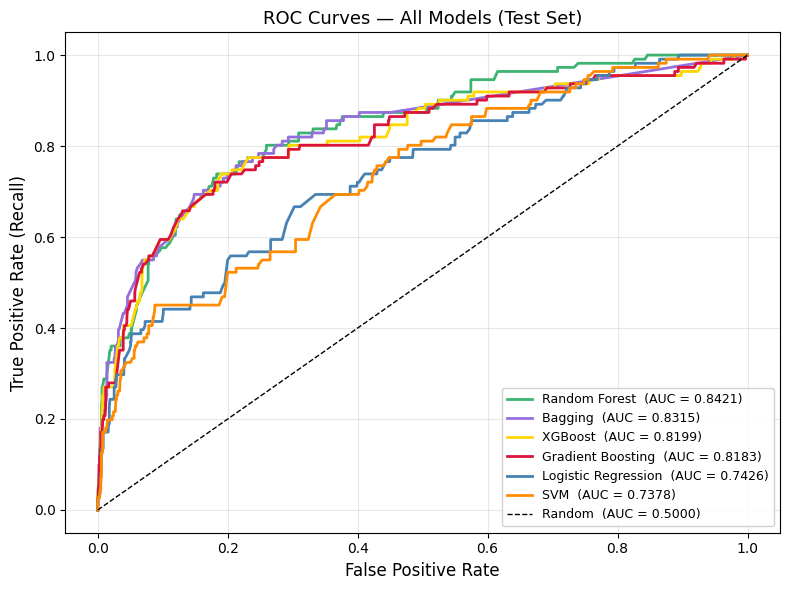

In [ ]:
# ── 5.2 ROC Curves ────────────────────────────────────────────────────────────

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Consistent colour per model
palette = {
    'Logistic Regression': 'steelblue',
    'SVM':                 'darkorange',
    'Random Forest':       'mediumseagreen',
    'Bagging':             'mediumpurple',
    'Gradient Boosting':   'crimson',
    'XGBoost':             'gold',
}

# Sort models by AUC descending using results already calculated in 5.1
models_sorted = dict(sorted(models.items(), key=lambda x: results_df.set_index('Model').loc[x[0], 'ROC-AUC'], reverse=True))

fig, ax = plt.subplots(figsize=(8, 6))

# Plot ROC curve for each model in order of descending AUC
for name, model in models_sorted.items():
    # Calculate and extract predicted probabilities for positive class (high-grade Cu)
    y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate false positive rate, true positive rate, and thresholds for ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
    
    # Calculate AUC using true labels and predicted probabilities
    auc = roc_auc_score(y_test, y_pred_prob)
    
    # Plot ROC curve using colour palette dict and AUC legend for easy comparison
    ax.plot(fpr, tpr,
            label=f'{name}  (AUC = {auc:.4f})',
            color=palette[name],
            linewidth=2)

# Random baseline
ax.plot([0, 1], [0, 1],
        color='black', linestyle='--', linewidth=1,
        label='Random  (AUC = 0.5000)')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curves — All Models (Test Set)', fontsize=13)
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**5.2 Outcome**

- All six models substantially outperform the random baseline — confirming that the geological signal in the core logging features is real and learnable from this dataset
- **Random Forest** achieves the highest AUC (0.8421) — meaning if a genuine high-grade interval and a background interval are randomly selected, the model will rank the high-grade one higher 84% of the time
- **Bagging** (0.8315), **XGBoost** (0.8199), and **Gradient Boosting** (0.8183) cluster tightly together — all four ensemble models clearly separate from the two linear models
- **Logistic Regression** (0.7426) and **SVM** (0.7378) trail by roughly 0.07 AUC points — a linear decision boundary is not sufficient to capture the interactions between lithology and alteration that drive Cu grade in this dataset
- All metrics in Section 5.1 were calculated at the default 0.5 probability threshold — in practice this threshold could be lowered to recover more high-grade intervals at the cost of additional false positives, depending on programme budget and risk tolerance

**5.3 Comparison Table**

A single table consolidating cross-validation F1 score from Section 4 and all four test-set metrics from Section 5.1 across all six models. Cross-validation F1 reflects how well each model generalised across training folds — test-set metrics reveal true out-of-sample performance on unseen data. A large drop between CV F1 and test F1 would indicate overfitting — the model memorised the training data rather than learning a generalisable signal.

In [28]:
# ── 5.3 Comparison Table ──────────────────────────────────────────────────────

# CV F1 scores recorded from Section 4 GridSearchCV results
cv_f1 = {
    'Logistic Regression': 0.3167,
    'SVM':                 0.3691,
    'Random Forest':       0.4098,
    'Bagging':             0.4116,
    'Gradient Boosting':   0.3657,
    'XGBoost':             0.3997,
}

# Add CV F1 column to results dataframe and sort by test F1
comparison_df = results_df.copy()
comparison_df.insert(1, 'CV F1', comparison_df['Model'].map(cv_f1))

display(comparison_df)

,Model,CV F1,Precision,Recall,F1,ROC-AUC
3,Bagging,0.4116,0.3396,0.6486,0.4458,0.8315
2,Random Forest,0.4098,0.3004,0.7117,0.4225,0.8421
5,XGBoost,0.3997,0.2872,0.7297,0.4122,0.8199
4,Gradient Boosting,0.3657,0.6818,0.2703,0.3871,0.8183
1,SVM,0.3691,0.3356,0.4505,0.3846,0.7378
0,Logistic Regression,0.3167,0.2160,0.5586,0.3116,0.7426


### 6. Best Model Deep Dive

Random Forest performed best overall — highest AUC (0.8421) and strong recall (0.7117) on the test set. This is consistent with the nature of exploration datasets — genuine high-grade intervals are rare by definition, and a 90/10 class imbalance is not unusual when working with real drill data. In this context AUC matters more than raw F1 score — the model's probability scores would be used to rank and prioritise intervals for follow-up, not just assign binary labels. A model that reliably separates the two classes across all thresholds is more operationally useful than one that performs well only at the default 0.5 cutoff.

The following three subsections examine what the model learned, where 
it succeeds and fails, and whether those patterns hold up geologically.

**6.1 Feature Importances**

Feature importances in Random Forest measure the mean decrease in Gini impurity each feature contributes across all trees in the ensemble — essentially how consistently a feature splits the data into cleaner high-grade and background subsets. Higher importance means the feature is doing more work to separate the classes.

Note that because categorical features like lithology and alteration type were one-hot encoded, each category scores independently. Where several encoded columns from the same original feature rank highly, that feature is collectively a strong predictor and is interpreted as a group rather than in isolation.

The 21 encoded features are plotted in descending order of importance. The results are then cross-referenced against the geological controls identified in Notebooks 03 and 04 to assess whether the model has learned a geologically meaningful signal or simply exploited statistical patterns in the data.

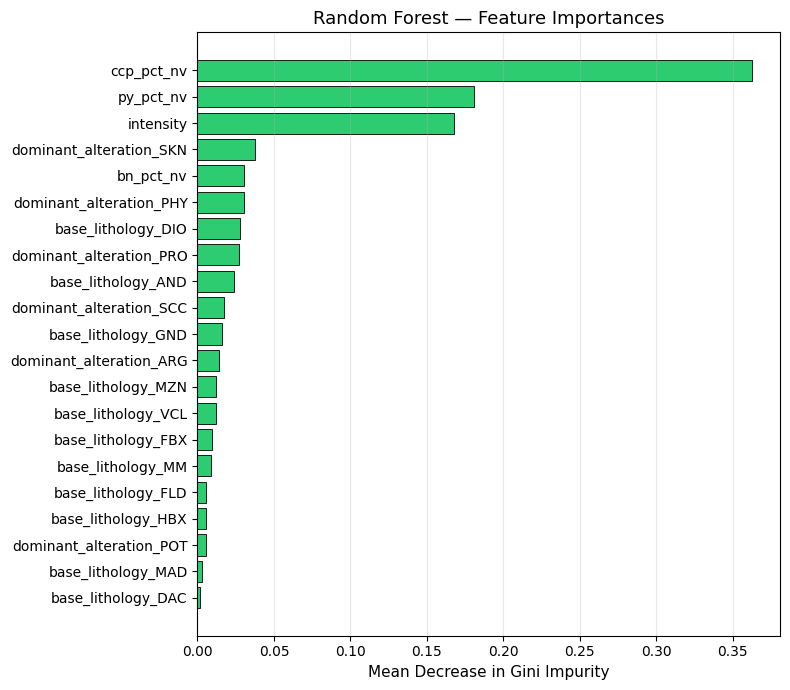

In [26]:
# ── 6.1 Feature Importances ────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import pandas as pd

# Extract feature importances from the trained Random Forest model
importances = rf_best.feature_importances_

# Assign feature names and their importances to a dataframe for plotting
importance_df = pd.DataFrame({
    'Feature':    feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

# Plot a horizontal bar chart of features ranked by importance
fig, ax = plt.subplots(figsize=(8, 7))

ax.barh(
    importance_df['Feature'],
    importance_df['Importance'],
    color='#2ecc71',
    edgecolor='black',
    linewidth=0.6
)

ax.set_xlabel('Mean Decrease in Gini Impurity', fontsize=11)
ax.set_title('Random Forest — Feature Importances', fontsize=13)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

**6.1 Outcome**

The feature importance plot reveals a clear hierarchy of geological controls on high-grade Cu mineralisation in the MPD dataset:

- **ccp_pct_nv** (chalcopyrite %) ranks as the single most important feature by a significant margin — chalcopyrite is the primary Cu-bearing sulphide in porphyry systems, making this result expected and a good indicator that the model has learned a geologically meaningful signal
- **py_pct_nv** (pyrite %) ranks second — pyrite and chalcopyrite commonly co-occur in porphyry mineralisation, and elevated pyrite is a reliable indicator of the broader sulphide envelope
- **intensity** (alteration intensity) ranks third — confirming that stronger hydrothermal overprinting is a key control on grade, consistent with the findings in Notebooks 03 and 04
- **dominant_alteration_SKN** is the highest-ranking categorical feature — skarn alteration is the primary high-grade host identified throughout this analysis and the model has independently recovered that signal
- **base_lithology_MM** (marble) ranks low despite being the reactive carbonate protolith that drives skarn formation — suggesting the model weights the alteration overprint more heavily than the host rock alone, which is geologically reasonable
- The remaining lithology and alteration columns form a long low-importance tail — their individual contributions are minor but collectively they provide context the model uses to distinguish background from mineralised intervals

Overall the feature importances are consistent with the geological interpretation developed in Notebooks 03 and 04 — the model has learned the correct controls on Cu mineralisation rather than exploiting statistical noise in the dataset.

**6.2 Confusion Matrix**

The confusion matrix breaks down model predictions on the test set into four categories: true positives (high-grade correctly flagged), true negatives (background correctly dismissed), false positives (background incorrectly flagged as high-grade), and false negatives (high-grade intervals missed entirely).

In an exploration context the cost of each error type is not equal — a false negative means a genuine high-grade interval is missed and potentially never followed up, while a false positive means a background interval gets flagged for additional work. Missing mineralisation is the more costly outcome, which is why high recall was prioritised throughout model selection

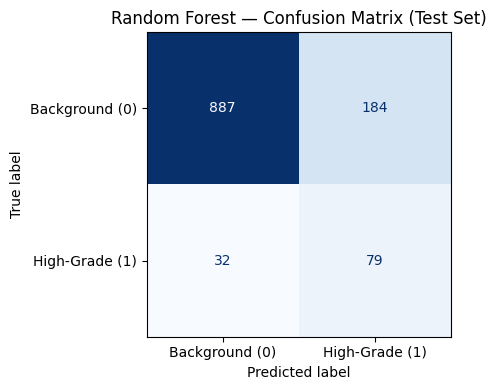

True Negatives  — background correctly dismissed:   887
False Positives — background flagged as high-grade: 184
False Negatives — high-grade intervals missed:      32
True Positives  — high-grade correctly flagged:     79

Recall:    0.7117  (79 of 111 high-grade intervals recovered)
Precision: 0.3004  (79 of 263 flagged intervals are genuine)


In [27]:
# ── 6.2 Confusion Matrix ──────────────────────────────────────────────────────

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Generate predictions on the test set using the best Random Forest model
y_pred_rf = rf_best.predict(X_test_scaled)

# Compute and plot the confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(5, 4))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Background (0)', 'High-Grade (1)']
).plot(ax=ax, colorbar=False, cmap='Blues')

ax.set_title('Random Forest — Confusion Matrix (Test Set)', fontsize=12)
plt.tight_layout()
plt.show()

# Print raw counts for reference
tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  — background correctly dismissed:   {tn}')
print(f'False Positives — background flagged as high-grade: {fp}')
print(f'False Negatives — high-grade intervals missed:      {fn}')
print(f'True Positives  — high-grade correctly flagged:     {tp}')
print()
print(f'Recall:    {tp / (tp + fn):.4f}  ({tp} of {tp+fn} high-grade intervals recovered)')
print(f'Precision: {tp / (tp + fp):.4f}  ({tp} of {tp+fp} flagged intervals are genuine)')

**6.2 Outcome**

- The model correctly recovered **79 of 111 high-grade intervals** on the test set — a recall of 0.7117, meaning roughly 7 in 10 genuine high-grade intervals would be flagged for follow-up
- **32 false negatives** — high-grade intervals the model missed entirely. In an operational context these represent the primary risk — mineralised intervals that would not be prioritised for follow-up based on model output alone. Geological judgement and additional logging would remain essential to catch what the model misses
- **184 false positives** — background intervals incorrectly flagged as high-grade. At a precision of 0.3004, roughly 1 in 3 flagged intervals is genuinely high-grade. In exploration this is an acceptable trade-off — the cost of assaying or re-logging a background interval is far lower than the cost of missing mineralisation
- **887 true negatives** — the model correctly dismisses the large majority of background intervals, which is expected given the 90/10 class imbalance
- These results are consistent with the recall-focused approach taken 
  throughout model selection — the model is tuned to catch mineralisation 
  rather than to be conservative, which is the appropriate behaviour for 
  an exploration prioritisation tool